 # Libraries

In [1]:
import numpy
import sklearn
import nltk
import pandas as pd

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import FreqDist
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from nltk.sentiment.vader import SentimentIntensityAnalyzer as stm


print(numpy.__version__)
print(sklearn.__version__)

# Some libraries were also written when questions were answered. You may not find
# them here. 

print("\n\nSuccessfully loaded all libraries.")

/Users/souravchakraborty/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/souravchakraborty/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


1.23.5
1.2.2


Successfully loaded all libraries.


## Task 1 – Data Loading and Preprocessing (5 Points)

In [2]:
df = pd.read_csv("stock_n_hl_news.csv")

# datetime format

df["Date"] = pd.to_datetime(df["Date"])
print("Shape of dataset:", df.shape)


# to show datetime changes: 
df.dtypes


Shape of dataset: (483, 7)


Date        datetime64[ns]
AAPL               float64
NASDAQ             float64
NYA                float64
SP500              float64
DJI                float64
Headline            object
dtype: object

In [3]:
df

,Date,AAPL,NASDAQ,NYA,SP500,DJI,Headline
0,2017-12-18,41.653164,6994.759766,12785.79980,2690.159912,24792.19922,France saves Marquis de Sade’s 120 Days of Sod...
1,2017-12-19,41.209293,6963.850098,12747.50000,2681.469971,24754.69922,House prices to fall in London and south-east ...
2,2017-12-20,41.164425,6960.959961,12747.59961,2679.250000,24726.69922,Hedge funds fail to stop 'billion-dollar brain...
3,2017-12-21,41.320255,6965.359863,12800.20020,2684.570068,24782.30078,Guardian Brexit watch \n\n\n Brexit helped p...
4,2017-12-22,41.320255,6959.959961,12797.40039,2683.340088,24754.09961,Jim Cramer broke down why owning fewer stocks ...
...,...,...,...,...,...,...,...
478,2020-07-13,93.371246,10390.839840,12014.70020,3155.219971,26085.80078,Salesforce CEO Marc Benioff told CNBC's Jim Cr...
479,2020-07-14,94.916397,10488.580080,12204.20020,3197.520020,26642.59961,"""Mad Money"" host Jim Cramer rings the lightnin..."
480,2020-07-15,95.569176,10550.490230,12391.29980,3226.560059,26870.09961,"""We've been able to capture these cultural mom..."
481,2020-07-16,94.393204,10473.830080,12350.09961,3215.570068,26734.69922,"""Look for the stocks of high-quality companies..."


In [4]:
df.shape

(483, 7)

## Task 2 – Market Trend Column (10 Points)

In [5]:
df["Trend"] = "Bullish"

df["Trend"] = ["Bullish" if i == 0 else "Bullish" if df["NASDAQ"].iloc[i] > df["NASDAQ"].iloc[i-1] 
               else "Bearish" for i in range(len(df["NASDAQ"]))]

df

# Here we create a column named Trend in the dataframe df. We then use a loop to enter values 
# in each row of the Trend column. Each row is either bullish or bearish based on the filter above. 

,Date,AAPL,NASDAQ,NYA,SP500,DJI,Headline,Trend
0,2017-12-18,41.653164,6994.759766,12785.79980,2690.159912,24792.19922,France saves Marquis de Sade’s 120 Days of Sod...,Bullish
1,2017-12-19,41.209293,6963.850098,12747.50000,2681.469971,24754.69922,House prices to fall in London and south-east ...,Bearish
2,2017-12-20,41.164425,6960.959961,12747.59961,2679.250000,24726.69922,Hedge funds fail to stop 'billion-dollar brain...,Bearish
3,2017-12-21,41.320255,6965.359863,12800.20020,2684.570068,24782.30078,Guardian Brexit watch \n\n\n Brexit helped p...,Bullish
4,2017-12-22,41.320255,6959.959961,12797.40039,2683.340088,24754.09961,Jim Cramer broke down why owning fewer stocks ...,Bearish
...,...,...,...,...,...,...,...,...
478,2020-07-13,93.371246,10390.839840,12014.70020,3155.219971,26085.80078,Salesforce CEO Marc Benioff told CNBC's Jim Cr...,Bearish
479,2020-07-14,94.916397,10488.580080,12204.20020,3197.520020,26642.59961,"""Mad Money"" host Jim Cramer rings the lightnin...",Bullish
480,2020-07-15,95.569176,10550.490230,12391.29980,3226.560059,26870.09961,"""We've been able to capture these cultural mom...",Bullish
481,2020-07-16,94.393204,10473.830080,12350.09961,3215.570068,26734.69922,"""Look for the stocks of high-quality companies...",Bearish


In [6]:
print(df["Trend"].value_counts())

# This goes to the Trend column and counts the unique number of bullish 
# and bearish rows and returns the number back to us. 

Trend
Bullish    275
Bearish    208
Name: count, dtype: int64


## Task 3 – Sentiment Analysis (10 Points)

### Perform NLP analysis on 'Headline' to obtain compound sentiment scores.

In [7]:
print(df["Headline"])

0      France saves Marquis de Sade’s 120 Days of Sod...
1      House prices to fall in London and south-east ...
2      Hedge funds fail to stop 'billion-dollar brain...
3      Guardian Brexit watch  \n\n\n  Brexit helped p...
4      Jim Cramer broke down why owning fewer stocks ...
                             ...                        
478    Salesforce CEO Marc Benioff told CNBC's Jim Cr...
479    "Mad Money" host Jim Cramer rings the lightnin...
480    "We've been able to capture these cultural mom...
481    "Look for the stocks of high-quality companies...
482    "Mad Money" host Jim Cramer recommended buying...
Name: Headline, Length: 483, dtype: object


In [8]:
scores = []

for s in df["Headline"]:
    stmscore = stm().polarity_scores(s)["compound"]
    scores.append(stmscore)

df["StmScore"] = scores

# Here we are not using individual sentiment scores such as positive, neutral, and negative. 
# Instead, we are getting a general / overall sentiment score for each row in the form of compound. 
# Compound combines the score of negative, postiive, and neutral component into a single value 
# rangining from -1 to 1. 



In [9]:
df

,Date,AAPL,NASDAQ,NYA,SP500,DJI,Headline,Trend,StmScore
0,2017-12-18,41.653164,6994.759766,12785.79980,2690.159912,24792.19922,France saves Marquis de Sade’s 120 Days of Sod...,Bullish,-0.9800
1,2017-12-19,41.209293,6963.850098,12747.50000,2681.469971,24754.69922,House prices to fall in London and south-east ...,Bearish,-0.9760
2,2017-12-20,41.164425,6960.959961,12747.59961,2679.250000,24726.69922,Hedge funds fail to stop 'billion-dollar brain...,Bearish,-0.5330
3,2017-12-21,41.320255,6965.359863,12800.20020,2684.570068,24782.30078,Guardian Brexit watch \n\n\n Brexit helped p...,Bullish,0.7579
4,2017-12-22,41.320255,6959.959961,12797.40039,2683.340088,24754.09961,Jim Cramer broke down why owning fewer stocks ...,Bearish,0.0065
...,...,...,...,...,...,...,...,...,...
478,2020-07-13,93.371246,10390.839840,12014.70020,3155.219971,26085.80078,Salesforce CEO Marc Benioff told CNBC's Jim Cr...,Bearish,0.9936
479,2020-07-14,94.916397,10488.580080,12204.20020,3197.520020,26642.59961,"""Mad Money"" host Jim Cramer rings the lightnin...",Bullish,-0.9522
480,2020-07-15,95.569176,10550.490230,12391.29980,3226.560059,26870.09961,"""We've been able to capture these cultural mom...",Bullish,0.9985
481,2020-07-16,94.393204,10473.830080,12350.09961,3215.570068,26734.69922,"""Look for the stocks of high-quality companies...",Bearish,0.9780


### Store scores in 'StmScore'. Categorize as 'positive' (>0.7), 'neutral' (-0.7 to 0.7), 'negative' (<-0.7) in 'Sentiment'.

In [10]:
sentiments = []

for s in df["StmScore"]:
    if s > 0.7:
        sentiments.append("positive")

    elif s < -0.7:
        sentiments.append("negative")

    else:
        sentiments.append("neutral")

df["Sentiment"] = sentiments

df

# Here were are creating a new column in the dataframe named Sentiment. It is created based on
# if-elif-else statements as shown above. 

,Date,AAPL,NASDAQ,NYA,SP500,DJI,Headline,Trend,StmScore,Sentiment
0,2017-12-18,41.653164,6994.759766,12785.79980,2690.159912,24792.19922,France saves Marquis de Sade’s 120 Days of Sod...,Bullish,-0.9800,negative
1,2017-12-19,41.209293,6963.850098,12747.50000,2681.469971,24754.69922,House prices to fall in London and south-east ...,Bearish,-0.9760,negative
2,2017-12-20,41.164425,6960.959961,12747.59961,2679.250000,24726.69922,Hedge funds fail to stop 'billion-dollar brain...,Bearish,-0.5330,neutral
3,2017-12-21,41.320255,6965.359863,12800.20020,2684.570068,24782.30078,Guardian Brexit watch \n\n\n Brexit helped p...,Bullish,0.7579,positive
4,2017-12-22,41.320255,6959.959961,12797.40039,2683.340088,24754.09961,Jim Cramer broke down why owning fewer stocks ...,Bearish,0.0065,neutral
...,...,...,...,...,...,...,...,...,...,...
478,2020-07-13,93.371246,10390.839840,12014.70020,3155.219971,26085.80078,Salesforce CEO Marc Benioff told CNBC's Jim Cr...,Bearish,0.9936,positive
479,2020-07-14,94.916397,10488.580080,12204.20020,3197.520020,26642.59961,"""Mad Money"" host Jim Cramer rings the lightnin...",Bullish,-0.9522,negative
480,2020-07-15,95.569176,10550.490230,12391.29980,3226.560059,26870.09961,"""We've been able to capture these cultural mom...",Bullish,0.9985,positive
481,2020-07-16,94.393204,10473.830080,12350.09961,3215.570068,26734.69922,"""Look for the stocks of high-quality companies...",Bearish,0.9780,positive


## Task 4 – Linear Regression Analysis (20 Points)

### Analyze the relationship between AAPL stock prices and 'StmScore'.

### Apply linear regression; assess if sentiment scores predict AAPL prices.

In [11]:
# need for regression analysis
import statsmodels.api as sm
from statsmodels.formula.api import ols

results = ols("AAPL ~ StmScore", data = df).fit()
print(results.summary())

# ols is used to help us perform the linear regression analysis on the df. 
# summary is also printed. 

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     13.16
Date:                Mon, 04 May 2026   Prob (F-statistic):           0.000316
Time:                        23:17:40   Log-Likelihood:                -1985.5
No. Observations:                 483   AIC:                             3975.
Df Residuals:                     481   BIC:                             3983.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     52.6547      0.675     78.044      0.0

### Interpret results and summarize findings in a Markdown cell.

The R^2 value is 0.027, which is very low. This means that approximately 2.7% of the variation in AAPL stock prices is explained by the independent variable, sentiment score.

The regression equation is:
AAPL = 52.6547 − 2.6368 × StmScore, indicating a negative relationship between AAPL prices and sentiment scores.

The p-values for both the intercept and the sentiment score are less than 0.05, suggesting that the relationship is statistically significant.

However, despite being statistically significant, the model has very low explanatory power. Therefore, sentiment scores are not strong predictors of AAPL stock prices.

## Task 5 – Logistic Regression for Trend Prediction (20 Points)

### Predict 'Trend' based on 'StmScore'.

In [12]:
df

,Date,AAPL,NASDAQ,NYA,SP500,DJI,Headline,Trend,StmScore,Sentiment
0,2017-12-18,41.653164,6994.759766,12785.79980,2690.159912,24792.19922,France saves Marquis de Sade’s 120 Days of Sod...,Bullish,-0.9800,negative
1,2017-12-19,41.209293,6963.850098,12747.50000,2681.469971,24754.69922,House prices to fall in London and south-east ...,Bearish,-0.9760,negative
2,2017-12-20,41.164425,6960.959961,12747.59961,2679.250000,24726.69922,Hedge funds fail to stop 'billion-dollar brain...,Bearish,-0.5330,neutral
3,2017-12-21,41.320255,6965.359863,12800.20020,2684.570068,24782.30078,Guardian Brexit watch \n\n\n Brexit helped p...,Bullish,0.7579,positive
4,2017-12-22,41.320255,6959.959961,12797.40039,2683.340088,24754.09961,Jim Cramer broke down why owning fewer stocks ...,Bearish,0.0065,neutral
...,...,...,...,...,...,...,...,...,...,...
478,2020-07-13,93.371246,10390.839840,12014.70020,3155.219971,26085.80078,Salesforce CEO Marc Benioff told CNBC's Jim Cr...,Bearish,0.9936,positive
479,2020-07-14,94.916397,10488.580080,12204.20020,3197.520020,26642.59961,"""Mad Money"" host Jim Cramer rings the lightnin...",Bullish,-0.9522,negative
480,2020-07-15,95.569176,10550.490230,12391.29980,3226.560059,26870.09961,"""We've been able to capture these cultural mom...",Bullish,0.9985,positive
481,2020-07-16,94.393204,10473.830080,12350.09961,3215.570068,26734.69922,"""Look for the stocks of high-quality companies...",Bearish,0.9780,positive


In [13]:
# needed for machine learning regression model training and testing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


# need to recode Trend as it only has bullish and bearish: 
# bullish = 1 and bearish = 0
# Dependent variable must be binary (1 or 0) for logistic regression. 

df["Trend"] = df["Trend"].map({"Bullish": 1, "Bearish": 0})

# X and Y: 

# # using double bracket here to go to the StmScore column in the dataframe, 
# then return the result in a dataframe so that is why we are using another bracket
# outside. 

x = df[["StmScore"]]
y = df["Trend"] # cannot use double brakcet here to avoid 2D error. 
# as sklearn expects a 1D array not 2D array. 

df

,Date,AAPL,NASDAQ,NYA,SP500,DJI,Headline,Trend,StmScore,Sentiment
0,2017-12-18,41.653164,6994.759766,12785.79980,2690.159912,24792.19922,France saves Marquis de Sade’s 120 Days of Sod...,1,-0.9800,negative
1,2017-12-19,41.209293,6963.850098,12747.50000,2681.469971,24754.69922,House prices to fall in London and south-east ...,0,-0.9760,negative
2,2017-12-20,41.164425,6960.959961,12747.59961,2679.250000,24726.69922,Hedge funds fail to stop 'billion-dollar brain...,0,-0.5330,neutral
3,2017-12-21,41.320255,6965.359863,12800.20020,2684.570068,24782.30078,Guardian Brexit watch \n\n\n Brexit helped p...,1,0.7579,positive
4,2017-12-22,41.320255,6959.959961,12797.40039,2683.340088,24754.09961,Jim Cramer broke down why owning fewer stocks ...,0,0.0065,neutral
...,...,...,...,...,...,...,...,...,...,...
478,2020-07-13,93.371246,10390.839840,12014.70020,3155.219971,26085.80078,Salesforce CEO Marc Benioff told CNBC's Jim Cr...,0,0.9936,positive
479,2020-07-14,94.916397,10488.580080,12204.20020,3197.520020,26642.59961,"""Mad Money"" host Jim Cramer rings the lightnin...",1,-0.9522,negative
480,2020-07-15,95.569176,10550.490230,12391.29980,3226.560059,26870.09961,"""We've been able to capture these cultural mom...",1,0.9985,positive
481,2020-07-16,94.393204,10473.830080,12350.09961,3215.570068,26734.69922,"""Look for the stocks of high-quality companies...",0,0.9780,positive


### Apply logistic regression; split data into training and testing sets.

In [14]:
#train_and_test_data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 10)

# this is logistic regression model 
logmodel = LogisticRegression(solver = "lbfgs")
# inputting the x and y columns 
logmodel.fit(x_train,y_train)

######## Predictions ##########
Y_predictions = logmodel.predict(x_test)

print("Y Test Values:\n")
print(y_test)

print("\nX Test Values:\n")
print(x_test)

print("\nY Train Values:\n")
print(y_train)

print("\nX Train Values:\n")
print(x_train)

print("\nY Predict Values:\n")
print(Y_predictions)

# Accuracy of the Logistic model: 
print("\nAcuracy of the Logistic Model is:\n ")
print(logmodel.score(x_test, y_test))

from sklearn.metrics import classification_report as report
print("\nClassification_Report:")
print(classification_report(y_test, Y_predictions, zero_division = 0))

# This shows corrects and incorrect classification 
from sklearn.metrics import confusion_matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, Y_predictions))

# the accuracy score, classification report, and confusion matrix are used to evaluate 
# the performance of the model and understand how well it predicts market trends.

Y Test Values:

479    1
98     1
398    1
260    1
310    0
      ..
142    1
339    0
459    1
192    0
68     0
Name: Trend, Length: 97, dtype: int64

X Test Values:

     StmScore
479   -0.9522
98     0.9986
398   -0.9973
260    0.9945
310    0.8784
..        ...
142   -0.9534
339    0.6349
459   -0.9968
192    0.9990
68    -0.9516

[97 rows x 1 columns]

Y Train Values:

291    1
438    1
212    0
226    0
471    1
      ..
369    0
320    1
15     1
125    0
265    0
Name: Trend, Length: 386, dtype: int64

X Train Values:

     StmScore
291    0.8599
438    0.9897
212    0.9596
226    0.9264
471   -0.9981
..        ...
369   -0.9505
320   -0.4179
15    -0.4767
125    0.9943
265    0.9904

[386 rows x 1 columns]

Y Predict Values:

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Acuracy of the Logistic Model is:
 
0.6082474226804123

### Discuss model performance and key takeaways in a Markdown cell.

Some notes:

    1. Accuracy = (TP + TN) / (TN + FN + FP + TP), Correct classifications / total classifications
    2. Recall = TP / (TP + FN), correctly predicted positives / all actual positives
    3. Precision = TP / (TP + FP), correctly predicted positives / all predicted positives
    4. The F1-score (harmonic mean) gives a balance between recall and precision.
        A score near 1 means that most of the predictions are correct.

This is definitely not a good model since it is just predicting the Bullish value. It did not predict a single Bearish value. The accuracy score is 61%, which means that the model correctly identified outcomes 61% of the time. However, this is misleading because the model is simply predicting the majority class (Bullish).

The precision score focuses on the accuracy of positive predictions. The precision score for Bearish is 0, and for Bullish is 0.61, again indicating that the logistic model is not performing well for this dataset.

The F1-score for Bullish is 76%, while for Bearish it is 0. This further suggests that the logistic model is not the right choice, as it fails to capture both classes effectively.

The confusion matrix shows that all 38 Bearish cases were misclassified as Bullish (false positives). It also shows that the model never predicted Bearish at all. This means the model is completely biased toward one class, Bullish.

# Task 6 – Advanced EDA (25 Points)

## Descriptive Statistics:

### Compute summary statistics (mean, median, standard deviation) for key columns (AAPL, NASDAQ, NYA, SP500, DJI, sentiment scores).

In [15]:
df.head(5)

,Date,AAPL,NASDAQ,NYA,SP500,DJI,Headline,Trend,StmScore,Sentiment
0,2017-12-18,41.653164,6994.759766,12785.79980,2690.159912,24792.19922,France saves Marquis de Sade’s 120 Days of Sod...,1,-0.9800,negative
1,2017-12-19,41.209293,6963.850098,12747.50000,2681.469971,24754.69922,House prices to fall in London and south-east ...,0,-0.9760,negative
2,2017-12-20,41.164425,6960.959961,12747.59961,2679.250000,24726.69922,Hedge funds fail to stop 'billion-dollar brain...,0,-0.5330,neutral
3,2017-12-21,41.320255,6965.359863,12800.20020,2684.570068,24782.30078,Guardian Brexit watch \n\n\n Brexit helped p...,1,0.7579,positive
4,2017-12-22,41.320255,6959.959961,12797.40039,2683.340088,24754.09961,Jim Cramer broke down why owning fewer stocks ...,0,0.0065,neutral


In [16]:
# We used describe() funtion to easily show the mean, std, and median (50% quartile)
# we then used .T to transpose the table for better readability. 

sum_statistics = df[["AAPL","NASDAQ","NYA","SP500","DJI","StmScore"]].describe().T

print("Summary statistics: \n")
print(sum_statistics)




Summary statistics: 

          count          mean          std           min           25%  \
AAPL      483.0     52.481323    14.975848     34.075405     41.711218   
NASDAQ    483.0   7868.327406   900.399860   6192.919922   7264.540039   
NYA       483.0  12464.099698   838.996522   8777.379883  12179.649905   
SP500     483.0   2819.119480   198.403574   2237.399902   2704.685059   
DJI       483.0  25261.111627  1547.373767  18591.900390  24516.699220   
StmScore  483.0      0.065752     0.926900     -0.999800     -0.977200   

                   50%           75%           max  
AAPL         45.651524     59.370152     95.569176  
NASDAQ     7628.279785   8033.669922  10617.440430  
NYA       12622.099610  12905.250000  14183.200200  
SP500      2786.570068   2888.700074   3386.149902  
DJI       25283.000000  25973.049805  29551.400390  
StmScore      0.634900      0.990200      0.999600  


### Identify outliers or anomalies.

In [17]:
columns = ["AAPL","NASDAQ","NYA","SP500","DJI","StmScore"]

# the below method is a general technique to detect outliers in the data set. 
# This has been applied to all of the columns and the results are printed. 

for column in columns:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"Outliers for {column} are:\n\n{outliers[column]}\n")


Outliers for AAPL are:

457    86.264069
461    86.078262
462    85.958458
463    85.992691
465    87.738327
466    89.611061
467    88.029243
468    89.197891
469    86.457199
470    88.449776
471    89.188103
472    89.019409
473    91.400681
474    91.117111
475    93.239227
476    93.640182
477    93.803986
478    93.371246
479    94.916397
480    95.569176
481    94.393204
482    94.202499
Name: AAPL, dtype: float64

Outliers for NASDAQ are:

361     9203.429688
363     9273.929688
364     9388.940430
365     9370.809570
366     9383.769531
           ...     
478    10390.839840
479    10488.580080
480    10550.490230
481    10473.830080
482    10503.190430
Name: NASDAQ, Length: 64, dtype: float64

Outliers for NYA are:

252    11036.799800
253    10769.799800
361    13997.700200
363    14042.599610
364    14183.200200
365    14110.000000
366    14110.200200
367    14102.000000
376    14024.900390
377    14035.000000
380    14054.099610
381    14137.000000
382    14099.000000
383

### Markdown Summary: Explain observations of outliers or anomalies.

The mean and median (50% quartile) are relatively close, which suggests there is no strong skewness in the data. 
The sentiment scores are close to 0, indicating that most headlines are neutral. 
Many outliers are observed in the stock prices, while no outliers are detected in the sentiment scores.

## Distribution Analysis:

### Create histograms for the distributions of stock indices and sentiment scores.

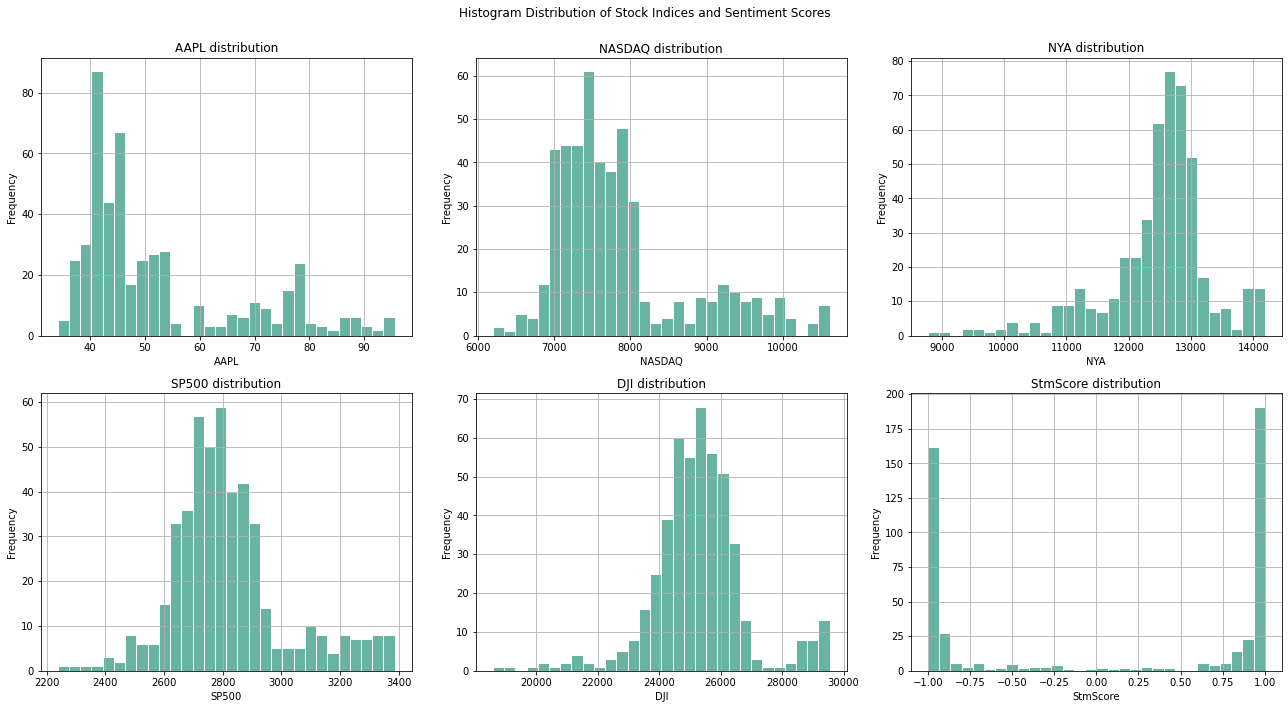

In [18]:
import matplotlib.pyplot as plt

# creating 2x3 of subplots to display histograms. 

fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize=(18, 10))
axes = axes.flatten()

# we will only need these columns. 
columns = ["AAPL", "NASDAQ", "NYA", "SP500", "DJI", "StmScore"]

# here we are adding the bar colors, labelling the x and y axis, and adding the title. 
# we are also looping through each column and plotting its distribution as histogram. 
# enumerate is used here to help us track the index and columns so each plot is placed in 
# correct subplot position. This algorithm was looked up online. 

for i, c in enumerate(columns):
    
    df[c].hist(ax = axes[i], edgecolor='white', color = "#69b3a2", bins = 30)
    
    axes[i].set_title(f"{c} distribution")
    axes[i].set_xlabel(c)
    axes[i].set_ylabel("Frequency")

plt.suptitle("Histogram Distribution of Stock Indices and Sentiment Scores\n")

# Adjust the layout. 
plt.tight_layout()

# Show the plot
plt.show()


### Check and discuss skewness or patterns.

### Markdown Summary: Describe distribution observations.

AAPL is right-skewed, with most prices falling between 40 and 60 and a longer tail on the right side. 
NASDAQ is also right-skewed, with most prices between 7000 and 8000 and a longer right tail. NYA is slightly left-skewed, with most prices between 11,000 and 13,000 and a longer tail on the left side. SP500 is approximately bell-shaped (normal) with slight right skewness, with most prices etween 2600 and 3000. DJI is also approximately normal with slight left skewness, with most prices between 24,000 and 27,000. Lastly, StmScore is bimodal, with values concentrated near -1 and 1, indicating that headlines are often strongly negative or strongly positive.

### Correlation Analysis:
1. Calculate and visualize correlations among stock indices and sentiment scores.
2. Use correlation matrices for visualization.
3. Markdown Summary: Discuss correlation findings.

              AAPL    NASDAQ       NYA     SP500       DJI  StmScore
AAPL      1.000000  0.941846 -0.085380  0.751729  0.344752 -0.163202
NASDAQ    0.941846  1.000000  0.151450  0.887213  0.546378 -0.093781
NYA      -0.085380  0.151450  1.000000  0.562041  0.863321  0.260141
SP500     0.751729  0.887213  0.562041  1.000000  0.861979  0.031803
DJI       0.344752  0.546378  0.863321  0.861979  1.000000  0.187811
StmScore -0.163202 -0.093781  0.260141  0.031803  0.187811  1.000000


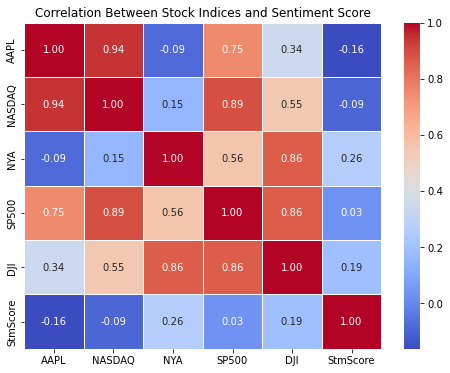

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = df[["AAPL", "NASDAQ", "NYA", "SP500", "DJI", "StmScore"]]

print(columns.corr())

corr_col = columns.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_col, annot = True, cmap = "coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Stock Indices and Sentiment Score")
plt.show()

# We are plotting the heatmap and the correlation matrix. 



The correlation matrix shows strong relationships among several stocks. AAPL and NASDAQ are highly correlated, with a correlation of 0.94. NYA and DJI are also strongly correlated with a correlation of 0.86, and SP500 and NASDAQ also show a high correlation of 0.89. These are just a few examples among many others.

The sentiment score shows very weak correlation with the other variables, suggesting little to no linear relationship.

Because the stock indices are highly correlated, this may indicate the presence of multicollinearity.

### Trend Analysis:
1. Plot time series graphs for stock trends and sentiment scores.
2. Highlight patterns or shifts using preattentive attributes.
3. Markdown Summary: Explain trend analysis observations.

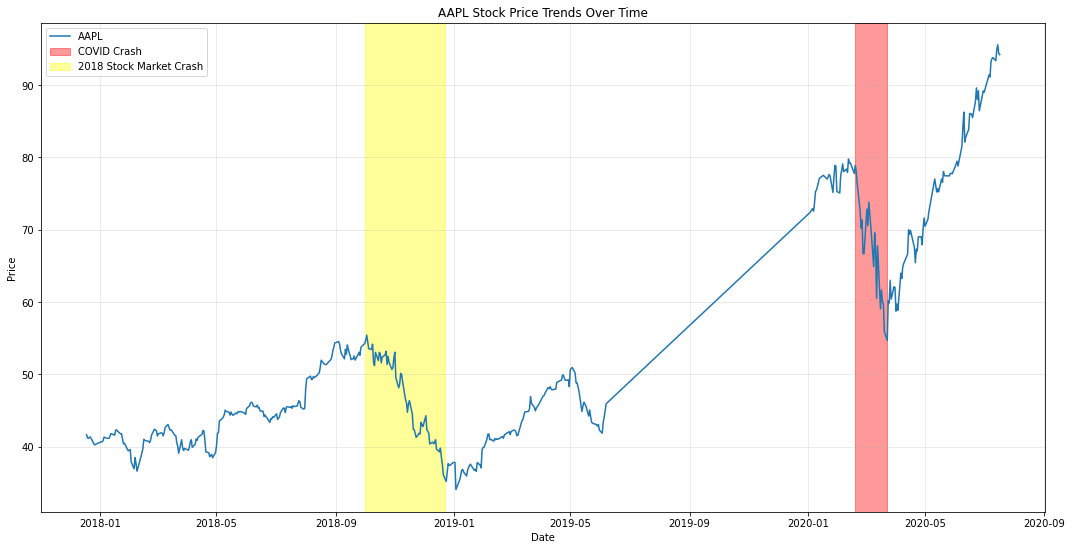

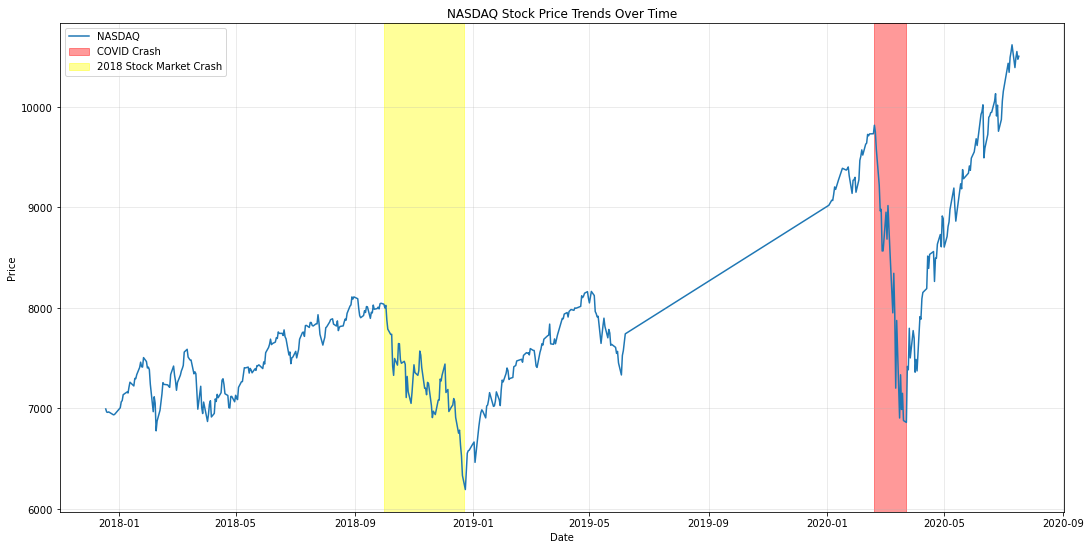

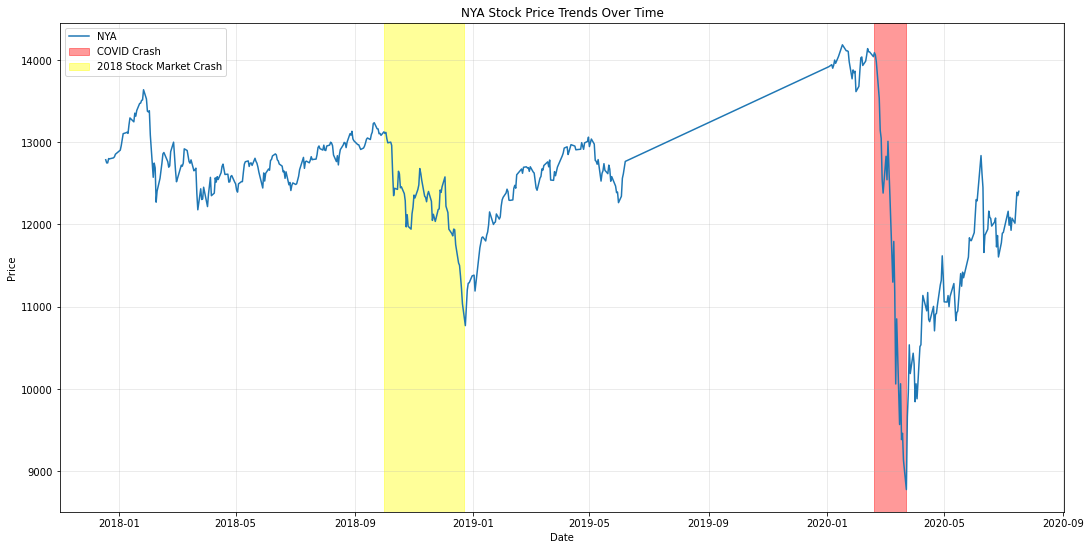

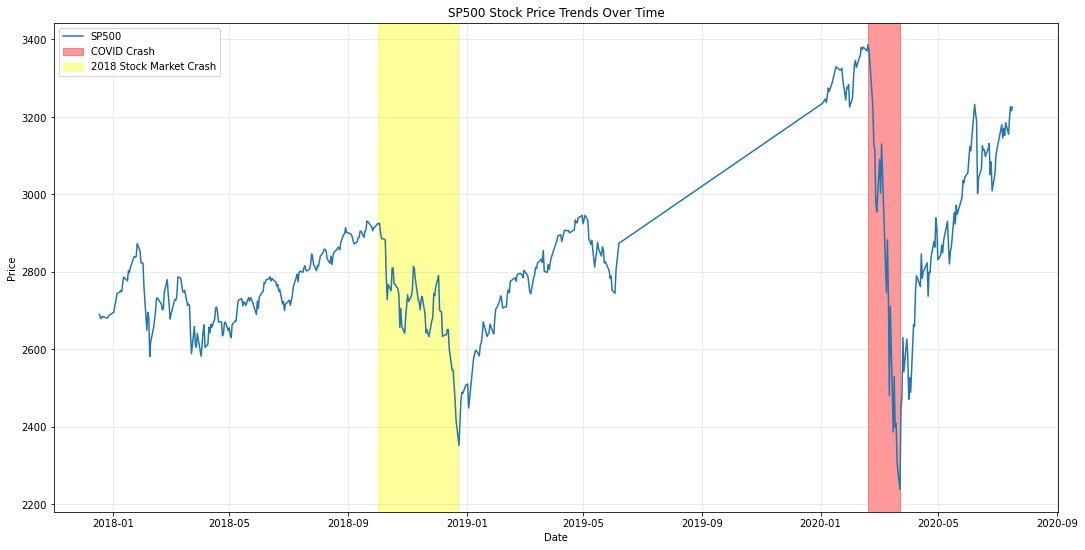

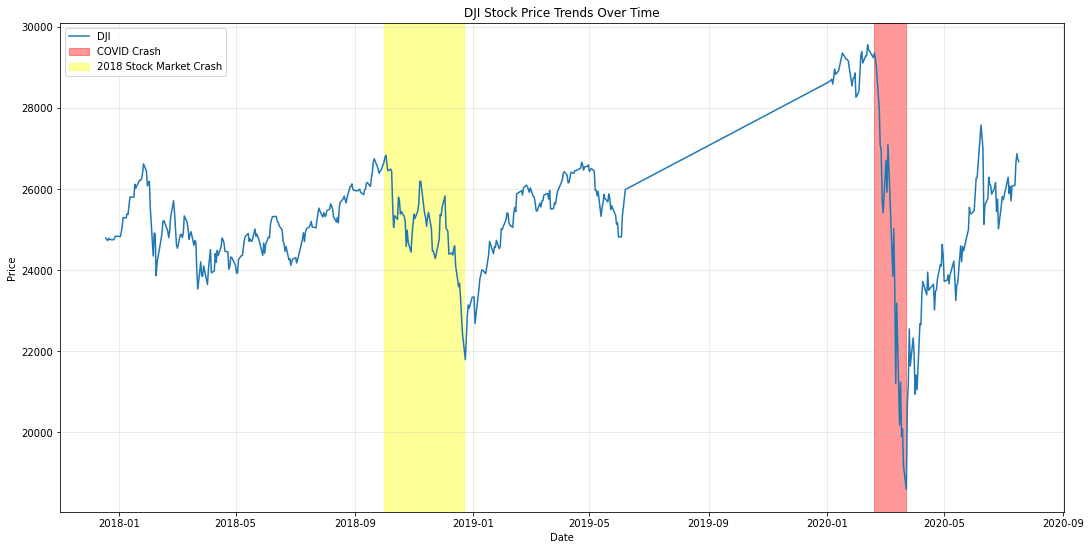

In [20]:
# we are sorting the df and using a variable to store the changes. 
# dont want to mess the original df. sorting the dates are neccessary here for time series anaysis. 

dfTrend = df.sort_values(by = "Date").reset_index(drop=True)

columns = ["AAPL", "NASDAQ", "NYA", "SP500", "DJI"]

for cols in columns:

    # plotting trends
    plt.figure(figsize = (18, 9))
    plt.plot(dfTrend["Date"].values, dfTrend[cols].values, label = cols)

    # highlighting COVID crash as a preattentive attribute (red shaded region)
     # with the help of axvspan. 
    plt.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"),
                color="red", alpha=0.4, label="COVID Crash")
    
    # highlighting 2018 Stock Marker Crash as a preattentive attribute (yellow shaded region)
    plt.axvspan(pd.Timestamp("2018-10-01"), pd.Timestamp("2018-12-23"),
            color="yellow", alpha=0.4, label="2018 Stock Market Crash")

    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.title(f"{cols} Stock Price Trends Over Time")
    plt.grid(alpha = 0.3)
    plt.show()
    

# need to plot StmScore alone as it has diffent dips than the stocks. 


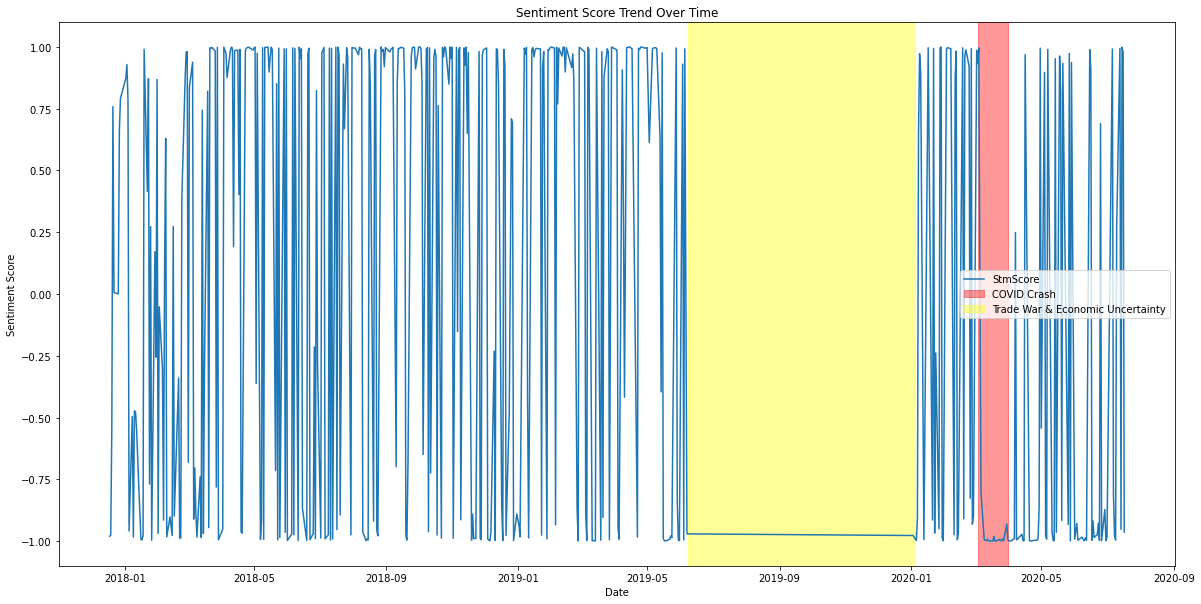

In [21]:
# plot trends
plt.figure(figsize = (20, 10))
plt.plot(dfTrend["Date"].values, dfTrend["StmScore"].values, label = "StmScore")

# highlighting COVID crash as a preattentive attribute (red shaded region)
plt.axvspan(pd.Timestamp("2020-03-03"), pd.Timestamp("2020-03-31"),
            color="red", alpha=0.4, label="COVID Crash")

# highlighting Trade War and Economic Uncertaintiy as a preattentive attribute (yellow shaded region)
plt.axvspan(pd.Timestamp("2019-06-8"), pd.Timestamp("2020-01-05"),
            color="yellow", alpha=0.4, label="Trade War & Economic Uncertainty")

# the plt.acvspan was looked up online in the python documentation section. 

plt.legend()
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.title("Sentiment Score Trend Over Time")
plt.show()


Sources: 
    
1. (Trade War) https://www.piie.com/blogs/trade-and-investment-policy-watch/2019/trump-has-gotten-china-lower-its-tariffs-just-toward
2. (Recession Concern) https://www.fuqua.duke.edu/duke-fuqua-insights/cfo-survey-december-2018

The time series plots show that all the stocks follow a similar pattern over time. They all significantly dipped during the 2018 market downturn, then recovered and increased, before crashing again during the COVID-19 crisis in 2020. After that, they showed growth again. This suggests that the stock market is highly sensitive to major economic events.

On the other hand, sentiment behaves differently. It does not follow a clear upward trend and instead shows constant fluctuations. This suggests that sentiment is more unstable, highly volatile, and less predictable than stock prices. Additionally, the sentiment score was extremely negative during the COVID-19 crisis in 2020 and during the trade war and economic uncertainty in 2019.

## Task 7 – Advanced Analysis (10 Points)

### Impact on AAPL Prices:
1. Use linear regression to assess the impact of indices (NASDAQ, NYA, SP500, DJI)
on AAPL stock prices.
2. Check for multicollinearity using VIF.

### Predictive Modeling:
1. Predict AAPL stock prices with regression models; assess accuracy.

### Markdown Summary:
1. Detail analysis and findings, highlighting multicollinearity issues if present.

In [22]:
df

,Date,AAPL,NASDAQ,NYA,SP500,DJI,Headline,Trend,StmScore,Sentiment
0,2017-12-18,41.653164,6994.759766,12785.79980,2690.159912,24792.19922,France saves Marquis de Sade’s 120 Days of Sod...,1,-0.9800,negative
1,2017-12-19,41.209293,6963.850098,12747.50000,2681.469971,24754.69922,House prices to fall in London and south-east ...,0,-0.9760,negative
2,2017-12-20,41.164425,6960.959961,12747.59961,2679.250000,24726.69922,Hedge funds fail to stop 'billion-dollar brain...,0,-0.5330,neutral
3,2017-12-21,41.320255,6965.359863,12800.20020,2684.570068,24782.30078,Guardian Brexit watch \n\n\n Brexit helped p...,1,0.7579,positive
4,2017-12-22,41.320255,6959.959961,12797.40039,2683.340088,24754.09961,Jim Cramer broke down why owning fewer stocks ...,0,0.0065,neutral
...,...,...,...,...,...,...,...,...,...,...
478,2020-07-13,93.371246,10390.839840,12014.70020,3155.219971,26085.80078,Salesforce CEO Marc Benioff told CNBC's Jim Cr...,0,0.9936,positive
479,2020-07-14,94.916397,10488.580080,12204.20020,3197.520020,26642.59961,"""Mad Money"" host Jim Cramer rings the lightnin...",1,-0.9522,negative
480,2020-07-15,95.569176,10550.490230,12391.29980,3226.560059,26870.09961,"""We've been able to capture these cultural mom...",1,0.9985,positive
481,2020-07-16,94.393204,10473.830080,12350.09961,3215.570068,26734.69922,"""Look for the stocks of high-quality companies...",0,0.9780,positive


In [23]:
# need for regression analysis

import statsmodels.api as sm
from statsmodels.formula.api import ols
# as before we are usign ols func here for simple linear regression and printing the summary. 

results = ols("AAPL ~ NASDAQ + NYA + SP500 + DJI ", data = df).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     2450.
Date:                Mon, 04 May 2026   Prob (F-statistic):          7.89e-317
Time:                        23:17:43   Log-Likelihood:                -1251.1
No. Observations:                 483   AIC:                             2512.
Df Residuals:                     478   BIC:                             2533.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -28.4243      2.453    -11.586      0.0

In [24]:
# VIF for Multicollinearity Testing
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# dependent variable is removed bc we want the VIF scores to be more accurate here. 
vif_columns = ["NASDAQ", "NYA", "SP500", "DJI"]


Vdf = add_constant(df[vif_columns])

for j in range (len(Vdf.columns)):
    
    print (f"The VIF for the {j}th column {Vdf.columns[j]} is: {variance_inflation_factor(Vdf.values, j):.2f}")

The VIF for the 0th column const is: 276.42
The VIF for the 1th column NASDAQ is: 45.05
The VIF for the 2th column NYA is: 9.78
The VIF for the 3th column SP500 is: 106.18
The VIF for the 4th column DJI is: 34.98


### Predictive Modeling:
### 1. Predict AAPL stock prices with regression models; assess accuracy.

In [25]:
x_cols = df[["NASDAQ", "NYA", "SP500", "DJI"]]

y_predict = results.predict(x_cols)

print(y_predict)

print("\n\nAccuracy:",results.rsquared)

# using the fitted OLS model (results) to generate predicted AAPL values 
# based on the predictor variables (NASDAQ, NYA, SP500, and DJI).

0      37.597864
1      37.189378
2      37.087027
3      36.946380
4      36.939749
         ...    
478    90.450797
479    90.982491
480    91.391892
481    90.968494
482    91.628915
Length: 483, dtype: float64


Accuracy: 0.9534928087006356


### Markdown Summary:
### 1. Detail analysis and findings, highlighting multicollinearity issues if present.

Multicolinearly: VIF (Variance Of Inflation Factor) = 1 / (1 - R^2). 

VIF < 5 is indicative of little to no multicollineratiy. 

VIF > 5 is indicative of high level of multicollineratiy.




As shown above, the OLS model gives an R^2 of 0.953, indicating that about 95.3% of the variation in AAPL prices can be explained by the predictor variables (NASDAQ, NYA, SP500, and DJI). This suggests that the model has strong predictive ability.

All of the predictor variables are statistically significant, as their p-values are less than 0.05.

The model also has a high F-statistic of 2450, indicating that the model does a good job of explaining the variation in the dependent variable. The p-value of the F-statistic is also extremely small (7.89e-317 < 0.05), confirming that the overall model is statistically significant.

The coefficients indicate that NASDAQ and SP500 have a positive relationship with AAPL, while NYA and DJI show slight negative relationships.

Severe multicollinearity is present, as all predictors have VIF scores above 5. The highest VIF is observed for SP500 (106.18), while the lowest is for NYA (9.78). This indicates that the stock indices are highly correlated with each other. The presence of multicollinearity reduces the reliability of the coefficient estimates, even though the model performs well overall.